Datos cargados


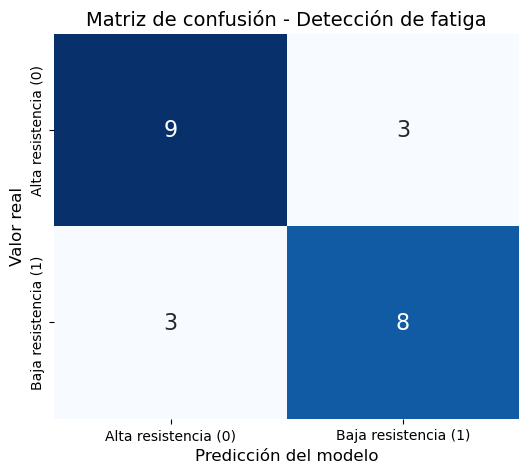


Exactitud (precisión): 73.91%

Interpretación de la matriz:
- Aciertos clase 0 (Verdaderos negativos): 9
- Aciertos clase 1 (Verdaderos positivos): 8
- Errores (confusiones): 6

Reporte de Clasificación:
                      precision    recall  f1-score   support

Alta Resistencia (0)       0.75      0.75      0.75        12
Baja Resistencia (1)       0.73      0.73      0.73        11

            accuracy                           0.74        23
           macro avg       0.74      0.74      0.74        23
        weighted avg       0.74      0.74      0.74        23


Importancia de las características (¿Qué tanto influyen en la fatiga?):
iEMG (Avg) [V.s]     0.331013
RMS (Avg) [% MVC]    0.276201
MNF (Avg) [Hz]       0.204144
MDF (Avg) [Hz]       0.188642
dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Carga
df = pd.read_csv('Extracted.csv',sep=';')
print("Datos cargados")

df.columns = df.columns.str.strip()
df.dropna(inplace=True)

# Creación de etiquetas
# Usamos la mediana para definir quién se fatiga rápido (1) y quién lento (0)
target_col = 'Time_Fatigue_Level_2 [s]'
median_time = df[target_col].median()

# 0: Alta Resistencia (Tiempo > Mediana)
# 1: Baja Resistencia (Tiempo <= Mediana)
df['Fatigue_Type'] = (df[target_col] <= median_time).astype(int)

# Seleccionamos las variables predictoras (Features)
features = ['RMS (Avg) [% MVC]', 'iEMG (Avg) [V.s]', 'MNF (Avg) [Hz]', 'MDF (Avg) [Hz]']
X = df[features]
y = df['Fatigue_Type']


# Entrenamiento del Random Forest
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred = rf_model.predict(X_test)

# Matriz de confusión
# Calcular la matriz numérica
cm = confusion_matrix(y_test, y_pred)

# Etiquetas para la gráfica
labels = ['Alta resistencia (0)', 'Baja resistencia (1)']

# Configurar el gráfico
plt.figure(figsize=(6, 5)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=labels, yticklabels=labels, annot_kws={"size": 16})

plt.title('Matriz de confusión - Detección de fatiga', fontsize=14)
plt.ylabel('Valor real', fontsize=12)
plt.xlabel('Predicción del modelo', fontsize=12)
plt.show()

# Métricas
acc = accuracy_score(y_test, y_pred)
print(f"\nExactitud (precisión): {acc:.2%}")
print("\nInterpretación de la matriz:")
print(f"- Aciertos clase 0 (Verdaderos negativos): {cm[0,0]}")
print(f"- Aciertos clase 1 (Verdaderos positivos): {cm[1,1]}")
print(f"- Errores (confusiones): {cm[0,1] + cm[1,0]}")

# Reporte detallado por clase
print('\nReporte de Clasificación:')
print(classification_report(y_test, y_pred, target_names=['Alta Resistencia (0)', 'Baja Resistencia (1)']))

# Extraemos qué variables fueron más útiles para el modelo
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

print('\nImportancia de las características (¿Qué tanto influyen en la fatiga?):')
print(importances)